# Deep Learning Fundamentals: Convolutional Neural Networks (CNNs) for Image Classification

In the previous sessions you built simple and deep neural networks using fully-connected layers. But there's a problem: **fully-connected networks don't scale well to images!**

Consider a 32×32 RGB image (like CIFAR-10):
- Flattened input: 32 × 32 × 3 = **3,072 features**
- With just 100 hidden neurons: **307,200 parameters** in the first layer alone!
- For 224×224 images (ImageNet): **150,528 features** → millions of parameters!

**Convolutional Neural Networks (CNNs)** solve this problem by:
- 🔍 Using **local receptive fields** (small filters that scan the image)
- 🔄 **Sharing weights** across spatial locations (drastically fewer parameters)
- 🏗️ Building **hierarchical features** (edges → textures → parts → objects)

In this notebook, we'll:
1. Explore how convolution works with toy examples
2. Understand padding, stride, and pooling
3. Build and train a CNN on CIFAR-10
4. Visualize what the CNN learned

## Learning Objectives

By the end of this tutorial you should be able to:

- **Explain** how kernels/filters detect features in images
- **Understand** how padding, stride, and pooling affect feature map dimensions
- **Implement** convolution and pooling layers in PyTorch
- **Build and train** a CNN for image classification
- **Visualize** learned filters and interpret what different layers detect
- **Compare** CNN efficiency vs fully-connected networks

<div class="alert alert-block alert-success">
<b>💡 BIG IDEA</b>

CNNs are the breakthrough that made modern computer vision possible. They're **translation-invariant** (detect features anywhere in the image) and **parameter-efficient** (millions of times fewer parameters than fully-connected networks for the same image size).
</div>

## 0. Setup and Imports

We use the same PyTorch stack as in previous sessions. The device will default to GPU if available, which significantly speeds up CNN training.

🎮 **GPU benefit**: CNNs involve many matrix operations that GPUs excel at. Training can be 10-50× faster on GPU!

In [1]:
import os
from pathlib import Path
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch.nn.functional as F
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

# Setup data directory
project_root = Path("..").resolve()
data_dir = project_root / "data"

# Detect best available device
device = torch.device(
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)

print(f"✓ Imports ready")
print(f"✓ Using device: {device}")
print(f"✓ Data directory: {data_dir}")

✓ Imports ready
✓ Using device: mps
✓ Data directory: /Users/jolan.heyse/Library/CloudStorage/OneDrive-VIB/Documents/Course Material/machine-learning-and-deep-learning-fundamentals/data


## Part 1: Understanding Convolution (The Foundation of CNNs)

Before building a full CNN, let's understand the **core operation: convolution**. 

A **convolution** slides a small filter (kernel) over an image, computing dot products at each position. Different kernels detect different features:
- **Edge detectors**: Find boundaries between regions
- **Sharpening filters**: Enhance edges and details
- **Blur filters**: Remove noise and smooth the image

Let's see this in action on a tiny toy image!

## 1. Convolution on a Toy Image

We start with a tiny 12×12 synthetic image with a bright square in the center. This lets you **directly see** how different kernels transform the image.

<div class="alert alert-block alert-info">
<b>QUESTIONS (before running)</b>

- What do you expect an **edge detector** to highlight?
- Where will the **sharpening kernel** have the strongest response?
- Will the **blur kernel** preserve or remove the sharp edges?
</div>

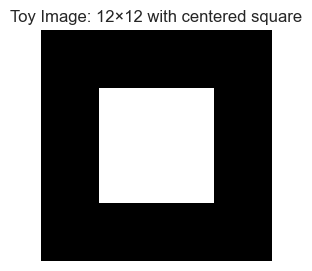

In [2]:
# Create a simple toy image: black background with white square in center
toy = torch.zeros(1, 1, 12, 12)  # Shape: [batch, channels, height, width]
toy[:, :, 3:9, 3:9] = 1.0  # White square from row 3-9, col 3-9

def show_single(img, title=None):
    """Helper function to display a single grayscale image"""
    plt.figure(figsize=(3, 3))
    plt.imshow(img, cmap="gray", vmin=0, vmax=1)
    if title is not None:
        plt.title(title)
    plt.axis("off")
    plt.show()

show_single(toy[0, 0].numpy(), "Toy Image: 12×12 with centered square")

### Apply Different Kernels

Now let's apply three classic image processing kernels:

1. **Edge detector**: Highlights boundaries (responds strongly where intensity changes)
2. **Sharpening**: Enhances edges and fine details
3. **Blur**: Smooths by averaging neighborhoods

Watch what happens to the square's edges!

1


RuntimeError: expected stride to be a single integer value or a list of 1 values to match the convolution dimensions, but got stride=[1, 1]

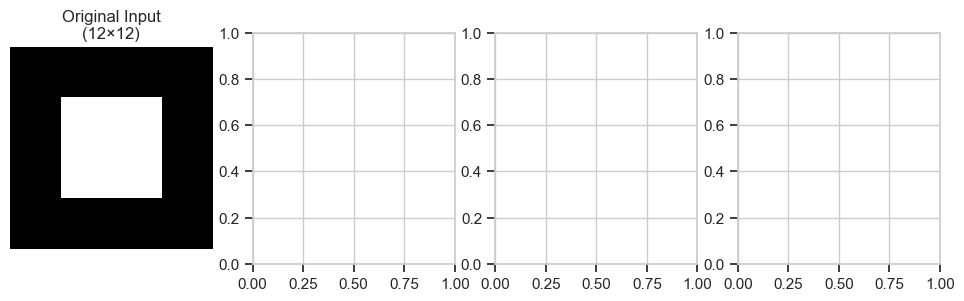

In [6]:
# Define three classic 3×3 kernels
kernels = {
    "edge": torch.tensor([
        [[-1, -1, -1],
         [-1,  8, -1],
         [-1, -1, -1]]
    ], dtype=torch.float32),
    
    "sharpen": torch.tensor([
        [[ 0, -1,  0],
         [-1,  5, -1],
         [ 0, -1,  0]]
    ], dtype=torch.float32),
    
    "blur": torch.ones(1, 1, 3, 3, dtype=torch.float32) / 9.0,  # Simple average
}

def apply_kernel(image, kernel, stride=1, padding=0):
    """Apply a convolution kernel to an image"""
    print(stride)
    return F.conv2d(image, kernel, stride=stride, padding=padding)

# Visualize results side-by-side
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

axes[0].imshow(toy[0, 0].numpy(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Original Input\n(12×12)")
axes[0].axis("off")

for ax, (name, k) in zip(axes[1:], kernels.items()):
    out = apply_kernel(toy, k)
    ax.imshow(out[0, 0].detach().numpy(), cmap="gray")
    ax.set_title(f"{name.capitalize()}\n{tuple(out.shape[-2:])}")
    ax.axis("off")

plt.tight_layout()
plt.show()

print("📊 Observations:")
print("  • Edge kernel: Strong response at square boundaries, zero in flat regions")
print("  • Sharpen kernel: Enhances edges while preserving the square")
print("  • Blur kernel: Smooths transitions, reduces sharpness")
print("  • Notice: Output is 10×10, not 12×12! (We'll explore why next)")

### Understanding the Results

<div class="alert alert-block alert-info">
<b>INTERPRETATION QUESTIONS</b>

- **Edge detector**: Why are there negative (dark) values? What does a negative response mean?
  - *Hint*: The kernel center is +8, surrounded by -1s
  
- **Boundary detection**: Why does the edge filter highlight only the square's boundary, not the interior?
  - *Hint*: Think about where pixel intensities *change*
  
- **Information loss**: The blur removes "sharpness" - what information is being lost?
  - *Hint*: Averaging neighbors reduces high-frequency details

💡 **Key insight**: Different kernels extract different features. CNNs **learn optimal kernels** during training!
</div>

## 2. Stride and Padding: Controlling Output Size

You noticed the output was 10×10, not 12×12! This happens because:
- A 3×3 kernel cannot be centered on edge pixels (without seeing outside the image)
- **Output size** = (Input size - Kernel size + 1) = 12 - 3 + 1 = 10

We have two tools to control this:

### **Padding**
- Adds zeros around the image border
- With `padding=1`: 12×12 → 14×14 (after padding) → 12×12 (after conv)
- Preserves spatial dimensions

### **Stride**  
- Step size when sliding the kernel
- `stride=1`: slide 1 pixel at a time (default)
- `stride=2`: slide 2 pixels at a time (outputs half the size)
- Used for **downsampling**

Let's see both in action!

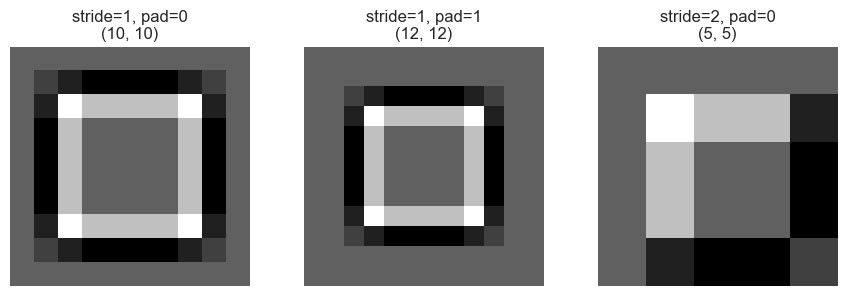

In [ ]:
edge_kernel = kernels["edge"]

# Test three configurations
settings = [
    (1, 0, "stride=1, pad=0 (default)"),
    (1, 1, "stride=1, pad=1 (same size)"),
    (2, 0, "stride=2, pad=0 (downsample)"),
]

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, (stride, padding, label) in zip(axes, settings):
    out = apply_kernel(toy, edge_kernel, stride=stride, padding=padding)
    ax.imshow(out[0, 0].detach().numpy(), cmap="gray")
    ax.set_title(f"{label}\nOutput: {tuple(out.shape[-2:])}")
    ax.axis("off")

plt.tight_layout()
plt.show()

print("📐 Dimension Math:")
print("  • stride=1, pad=0: (12-3+1) = 10×10")
print("  • stride=1, pad=1: (12+2-3+1) = 12×12 (preserved!)")
print("  • stride=2, pad=0: (12-3)//2+1 = 5×5 (half size)")

### Multi-Channel Convolution (RGB Images)

Real images have 3 color channels (RGB). How does convolution work here?

**Key concept**: A 3-channel input needs a 3-channel kernel (one per color). The convolution **sums over all channels** at each position.

- Input: H × W × 3 (height, width, RGB)
- Kernel: 3 × 3 × 3 (spatial 3×3, depth 3 for RGB)
- Output: H × W × 1 (single feature map)

For multiple output features, we use **multiple kernels** (each producing one feature map).

<div class="alert alert-block alert-info">
<b>QUESTION</b>

If we want 64 output feature maps from a 3-channel input using 3×3 kernels:
- How many kernels do we need? 
- What's the total number of weights?

*Answer*: 64 kernels, each 3×3×3 = 27 weights → **1,728 weights total** (plus 64 biases)
</div>

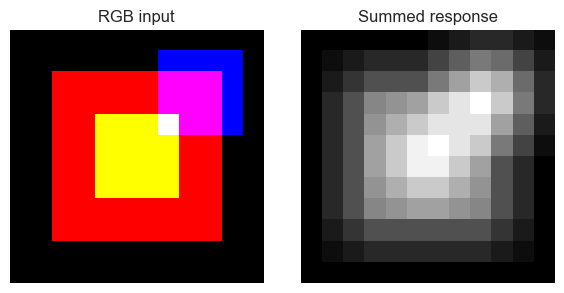

In [ ]:
# Create a toy RGB image with different patterns per channel
toy_rgb = torch.zeros(1, 3, 12, 12)
toy_rgb[:, 0, 2:10, 2:10] = 1.0  # Red channel: large square
toy_rgb[:, 1, 4:8, 4:8] = 1.0    # Green channel: small square
toy_rgb[:, 2, 1:5, 7:11] = 1.0   # Blue channel: offset square

# Simple 3-channel convolution (blur across all channels)
conv_rgb = nn.Conv2d(3, 1, kernel_size=3, padding=1, bias=False)
with torch.no_grad():
    conv_rgb.weight[:] = 1.0 / 9.0  # Average all RGB values in 3×3 neighborhood

out_rgb = conv_rgb(toy_rgb)

fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# Show RGB input
axes[0].imshow(toy_rgb[0].permute(1, 2, 0).numpy())
axes[0].set_title("RGB Input\n(each channel has different pattern)")
axes[0].axis("off")

# Show summed response
axes[1].imshow(out_rgb[0, 0].detach().numpy(), cmap="gray")
axes[1].set_title("Single Output Feature Map\n(sum of responses from all 3 channels)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("🎨 Multi-channel convolution:")
print(f"  • Input shape: {toy_rgb.shape} (batch, RGB, height, width)")
print(f"  • Kernel shape: {conv_rgb.weight.shape} (out_ch, in_ch, kH, kW)")
print(f"  • Output shape: {out_rgb.shape} (batch, 1 feature map, height, width)")

## 3. Pooling: Downsampling for Efficiency

**Pooling** reduces spatial resolution while retaining important features. Benefits:
- 🔽 Reduces computation in deeper layers
- 🎯 Adds translation invariance (small shifts don't change pooled output)
- 📉 Reduces overfitting risk

### Common pooling operations:

1. **Max pooling**: Takes maximum value in each neighborhood
   - Preserves strongest activations
   - Most common in modern CNNs
   
2. **Average pooling**: Takes mean value in each neighborhood
   - Smoother but loses some detail
   
3. **Strided convolution**: Convolution with stride > 1
   - Learnable downsampling (kernel weights are learned)
   - Increasingly popular alternative to pooling

<div class="alert alert-block alert-info">
<b>QUESTIONS (before running)</b>

- Which operation will preserve more texture detail: max or average pooling?
- How is strided convolution similar to pooling? How is it different?
- Why might max pooling be preferred for detecting features?
</div>

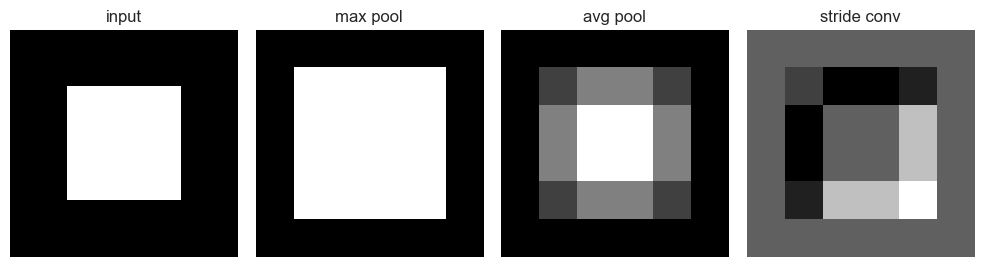

In [ ]:
# Define three downsampling operations
max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)
stride_conv = nn.Conv2d(1, 1, kernel_size=3, stride=2, padding=1, bias=False)

# Use edge kernel for strided conv
with torch.no_grad():
    stride_conv.weight[:] = edge_kernel

# Apply all three
max_out = max_pool(toy)
avg_out = avg_pool(toy)
stride_out = stride_conv(toy)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

axes[0].imshow(toy[0, 0].numpy(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"Input\n{tuple(toy.shape[-2:])}")
axes[0].axis("off")

axes[1].imshow(max_out[0, 0].detach().numpy(), cmap="gray")
axes[1].set_title(f"Max Pool\n{tuple(max_out.shape[-2:])}")
axes[1].axis("off")

axes[2].imshow(avg_out[0, 0].detach().numpy(), cmap="gray")
axes[2].set_title(f"Average Pool\n{tuple(avg_out.shape[-2:])}")
axes[2].axis("off")

axes[3].imshow(stride_out[0, 0].detach().numpy(), cmap="gray")
axes[3].set_title(f"Strided Conv\n{tuple(stride_out.shape[-2:])}")
axes[3].axis("off")

plt.tight_layout()
plt.show()

print("📊 Comparison:")
print("  • Max pooling: Preserves sharp edges (takes brightest pixels)")
print("  • Avg pooling: Smoother output (averages neighborhoods)")
print("  • Strided conv: Learned downsampling (kernel is trainable)")
print(f"  • All reduce size: {tuple(toy.shape[-2:])} → {tuple(max_out.shape[-2:])}")

---
## Part 2: Building a Real CNN on CIFAR-10

Now that you understand the building blocks, let's build a real CNN! We'll use **CIFAR-10**, a classic computer vision dataset with 60,000 tiny 32×32 color images in 10 classes.

### Why CIFAR-10?
- Small enough to train quickly on CPU/GPU
- Real-world complexity (unlike toy datasets)
- Standard benchmark for comparing architectures
- Good stepping stone before ImageNet

Let's load the data!

## 4. Load CIFAR-10 Dataset

We'll try to download CIFAR-10 from the internet. If that fails (e.g., offline or network issues), we have a small fallback dataset so you can still complete the tutorial.

**CIFAR-10 classes**: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

In [ ]:
# CIFAR-10 class names
cifar10_labels = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

# Standard normalization for CIFAR-10 (computed from training set)
mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.ToTensor(),  # Convert PIL Image to tensor [0, 1]
    transforms.Normalize(mean, std),  # Normalize to mean=0, std=1
])

def try_load_cifar10(data_dir, transform):
    """Attempt to download CIFAR-10"""
    try:
        train_data = datasets.CIFAR10(root=data_dir, train=True, download=True, transform=transform)
        test_data = datasets.CIFAR10(root=data_dir, train=False, download=True, transform=transform)
        return train_data, test_data, False
    except Exception as error:
        print(f"⚠️ CIFAR-10 download failed: {error}")
        print("→ Using fallback dataset instead")
        return None, None, True

def load_fallback_npz(npz_path):
    """Load small fallback dataset if download fails"""
    data = np.load(npz_path)
    x_train = torch.tensor(data["x_train"], dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
    y_train = torch.tensor(data["y_train"], dtype=torch.long)
    x_test = torch.tensor(data["x_test"], dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
    y_test = torch.tensor(data["y_test"], dtype=torch.long)

    # Apply same normalization
    mean_t = torch.tensor(mean).view(1, 3, 1, 1)
    std_t = torch.tensor(std).view(1, 3, 1, 1)
    x_train = (x_train - mean_t) / std_t
    x_test = (x_test - mean_t) / std_t

    train_ds = TensorDataset(x_train, y_train)
    test_ds = TensorDataset(x_test, y_test)
    return train_ds, test_ds

# Try to load CIFAR-10
train_dataset, test_dataset, used_fallback = try_load_cifar10(data_dir, train_transform)

if used_fallback:
    fallback_path = data_dir / "cifar10_fallback.npz"
    train_dataset, test_dataset = load_fallback_npz(fallback_path)

dataset_name = "CIFAR-10 (fallback)" if used_fallback else "CIFAR-10 (full)"
print(f"✓ Loaded {dataset_name}")
print(f"  • Training samples: {len(train_dataset)}")
print(f"  • Test samples: {len(test_dataset)}")

/Users/jolan.heyse/Library/CloudStorage/OneDrive-VIB/Documents/Course Material/machine-learning-and-deep-learning-fundamentals/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


False

## 5. Visualize Sample Images

Let's peek at some training images to get a feel for the data. Notice how small 32×32 images are - yet CNNs can learn to classify them accurately!

<div class="alert alert-block alert-info">
<b>OBSERVATION QUESTIONS</b>

- Can you recognize objects in these tiny images?
- Are some classes harder to distinguish than others (e.g., cat vs dog)?
- How might data quality affect model performance?
</div>

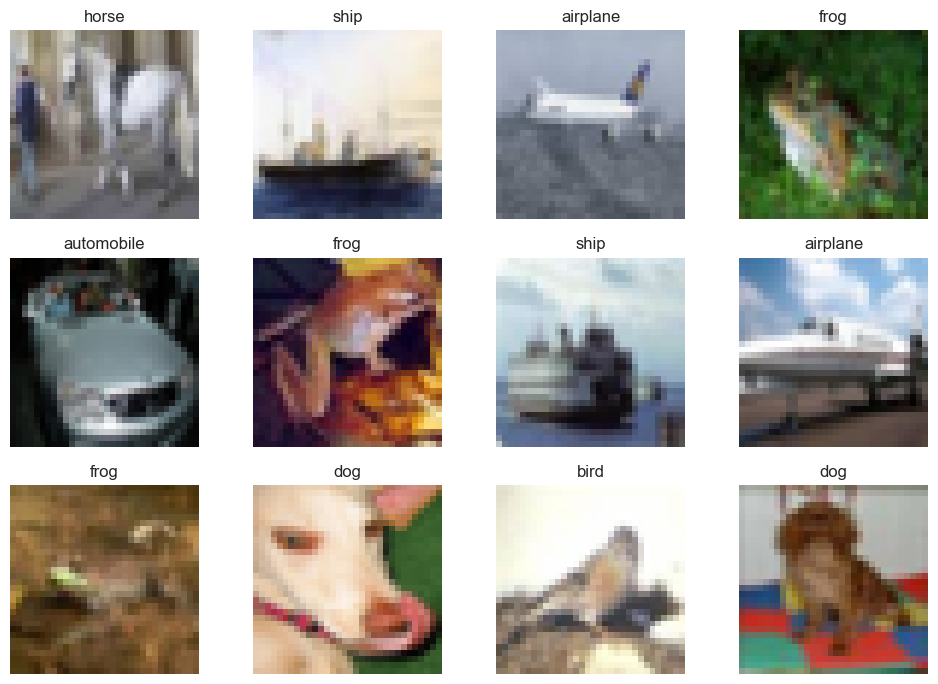

In [ ]:
def denormalize(tensor, mean, std):
    """Reverse normalization for visualization"""
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    return tensor * std_t + mean_t

def show_batch(dataset, labels, n=12):
    """Display a grid of random samples"""
    indices = np.random.choice(len(dataset), size=n, replace=False)
    fig, axes = plt.subplots(3, 4, figsize=(10, 7))
    
    for ax, idx in zip(axes.flatten(), indices):
        image, label = dataset[idx]
        if isinstance(image, torch.Tensor):
            image = denormalize(image, mean, std).clamp(0, 1)
            image = image.permute(1, 2, 0).numpy()
        ax.imshow(image)
        ax.set_title(labels[int(label)], fontsize=10)
        ax.axis("off")
    
    plt.suptitle("Random CIFAR-10 Training Samples (32×32 RGB)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, cifar10_labels)

## 6. Prepare Data Loaders

We create train/validation splits and DataLoaders for efficient mini-batch training.

**Why validation set?**
- Monitor overfitting during training
- Select best model (best val accuracy)
- Never touch test set until final evaluation!

**Mini-batch benefits:**
- Memory efficient (don't load entire dataset at once)
- Faster convergence (more frequent weight updates)
- Better generalization (noise in gradients acts as regularization)

In [ ]:
# Create validation split from training data
val_size = 5000 if len(train_dataset) > 5000 else max(10, len(train_dataset) // 5)
train_size = len(train_dataset) - val_size

train_ds, val_ds = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42),
)

# Adjust batch size based on dataset
batch_size = 128 if not used_fallback else 32
loader_kwargs = dict(num_workers=0, pin_memory=torch.cuda.is_available())

# Create DataLoaders
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, **loader_kwargs)

print("✓ Data loaders ready:")
print(f"  • Train: {len(train_ds)} samples ({len(train_loader)} batches)")
print(f"  • Validation: {len(val_ds)} samples ({len(val_loader)} batches)")
print(f"  • Test: {len(test_dataset)} samples ({len(test_loader)} batches)")
print(f"  • Batch size: {batch_size}")

(45000, 5000, 10000)

## 7. Define a Compact CNN Architecture

Time to build our CNN! We'll use a simple but effective architecture:

### Architecture Overview:
```
Input: 32×32×3 (RGB image)
  ↓
[Conv 32 filters (3×3) + BatchNorm + ReLU + MaxPool] → 16×16×32
  ↓
[Conv 64 filters (3×3) + BatchNorm + ReLU + MaxPool] → 8×8×64
  ↓
[Conv 128 filters (3×3) + BatchNorm + ReLU + MaxPool] → 4×4×128
  ↓
Flatten → 2048 features
  ↓
[Dense 128 + ReLU + Dropout(0.3)] → 128 features
  ↓
[Dense 10] → 10 class scores
  ↓
Output: Class probabilities (via softmax in loss)
```

### Design choices:
- **3 conv blocks**: Gradually increase filters (32→64→128)
- **BatchNorm**: Stabilizes training
- **MaxPool**: Reduces spatial dimensions (32→16→8→4)
- **Dropout**: Prevents overfitting in classifier
- **Small kernels (3×3)**: Efficient and effective

<div class="alert alert-block alert-info">
<b>ARCHITECTURE QUESTIONS</b>

- Why do we increase the number of filters (32→64→128) as we go deeper?
- Why is the final feature map 4×4×128 instead of 1×1×large?
- How many parameters would a fully-connected network need for the same input?
</div>

In [ ]:
class SmallCNN(nn.Module):
    """Compact CNN for CIFAR-10 classification"""
    def __init__(self, num_classes=10):
        super().__init__()
        
        # Feature extraction: 3 convolutional blocks
        self.features = nn.Sequential(
            # Block 1: 32×32×3 → 16×16×32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 2: 16×16×32 → 8×8×64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 3: 8×8×64 → 4×4×128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),  # 4×4×128 = 2048 features
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# Initialize model
model = SmallCNN(num_classes=10).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\n📊 Model Statistics:")
print(f"  • Total parameters: {total_params:,}")
print(f"  • Trainable parameters: {trainable_params:,}")
print(f"\n💡 Compare to fully-connected: 32×32×3 × 128 = {32*32*3*128:,} parameters (just first layer!)")

SmallCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout

## 8. Train the CNN

Time to train! We'll use:
- **Cross-entropy loss**: Standard for classification
- **Adam optimizer**: Adaptive learning rates
- **Learning rate 1e-3**: Good default for Adam

We keep epochs modest (~10) so training completes quickly while still showing clear learning.

<div class="alert alert-block alert-warning">
<b>⏱️ TRAINING TIME</b>

- CPU: ~2-5 minutes per epoch
- GPU: ~10-30 seconds per epoch
- Full training: 5-10 minutes total

Grab a coffee and watch the loss decrease! ☕
</div>

In [ ]:
def accuracy_from_logits(logits, targets):
    preds = torch.argmax(logits, dim=1)
    return (preds == targets).float().mean().item()


def evaluate_loader(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    total_items = 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            logits = model(inputs)
            loss = criterion(logits, targets)

            batch_size = inputs.size(0)
            total_loss += loss.item() * batch_size
            total_acc += accuracy_from_logits(logits, targets) * batch_size
            total_items += batch_size

    return total_loss / total_items, total_acc / total_items


def fit(model, train_loader, val_loader, criterion, optimizer, device, epochs):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_acc = 0.0
        total_items = 0

        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()

            batch_size = inputs.size(0)
            running_loss += loss.item() * batch_size
            running_acc += accuracy_from_logits(logits, targets) * batch_size
            total_items += batch_size

        train_loss = running_loss / total_items
        train_acc = running_acc / total_items
        val_loss, val_acc = evaluate_loader(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:02d} | train loss {train_loss:.3f} acc {train_acc:.3f} | val loss {val_loss:.3f} acc {val_acc:.3f}")

    return history


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 10 if not used_fallback else 8
history = fit(model, train_loader, val_loader, criterion, optimizer, device, epochs)

Epoch 01 | train loss 1.352 acc 0.509 | val loss 1.081 acc 0.611
Epoch 02 | train loss 0.988 acc 0.650 | val loss 0.865 acc 0.694
Epoch 03 | train loss 0.856 acc 0.699 | val loss 0.857 acc 0.703
Epoch 04 | train loss 0.765 acc 0.732 | val loss 0.715 acc 0.742
Epoch 05 | train loss 0.695 acc 0.756 | val loss 0.763 acc 0.735
Epoch 06 | train loss 0.643 acc 0.773 | val loss 0.706 acc 0.753
Epoch 07 | train loss 0.589 acc 0.792 | val loss 0.726 acc 0.744
Epoch 08 | train loss 0.542 acc 0.810 | val loss 0.668 acc 0.764
Epoch 09 | train loss 0.496 acc 0.825 | val loss 0.665 acc 0.764
Epoch 10 | train loss 0.459 acc 0.836 | val loss 0.667 acc 0.770


### Understanding the Training Progress

Watch the printed output:
- **Train loss/acc**: How well the model fits training data
- **Val loss/acc**: How well it generalizes to unseen data

**Good signs:**
- ✅ Train and val metrics both improving
- ✅ Val accuracy within ~5% of train accuracy

**Warning signs:**
- ⚠️ Val loss increasing while train loss decreases (overfitting!)
- ⚠️ Very large gap between train and val accuracy

## 9. Visualize Training Curves

Learning curves tell the story of training. Let's see how our CNN learned!

<div class="alert alert-block alert-info">
<b>INTERPRETATION QUESTIONS</b>

- At what epoch did the model converge (stop improving significantly)?
- Is there evidence of overfitting (train >> val)?
- Would training for more epochs help or hurt?
</div>

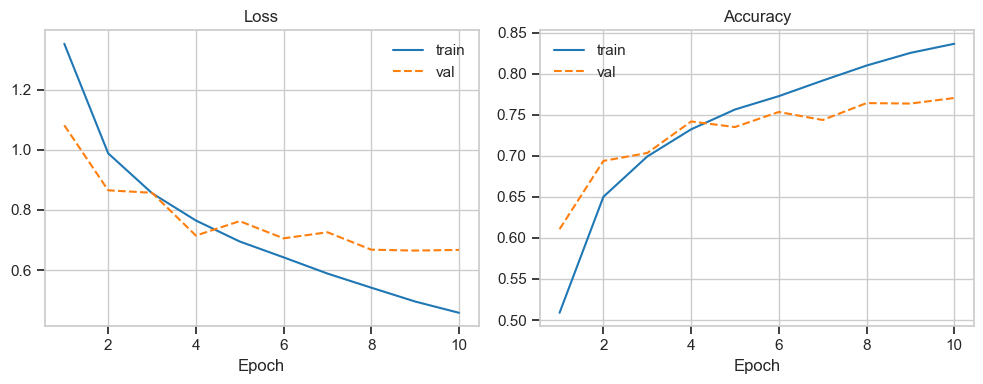

In [ ]:
epochs_axis = np.arange(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(epochs_axis, history["train_loss"], label="train")
axes[0].plot(epochs_axis, history["val_loss"], label="val", linestyle="--")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_axis, history["train_acc"], label="train")
axes[1].plot(epochs_axis, history["val_acc"], label="val", linestyle="--")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

print("📈 Training curves plotted")

## 9. Evaluate on the test set

Test loss: 0.707 | Test accuracy: 0.767


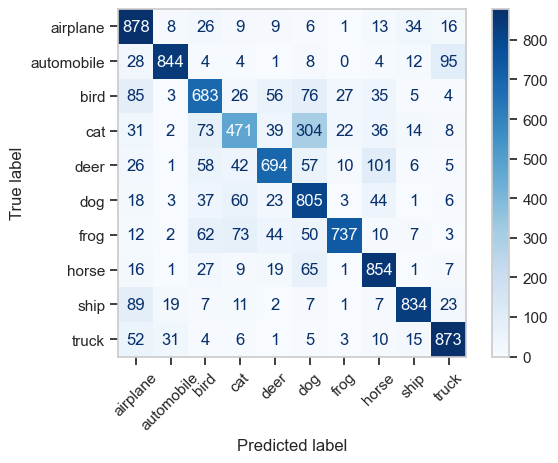

In [ ]:
test_loss, test_acc = evaluate_loader(model, test_loader, criterion, device)
print(f"Test loss: {test_loss:.3f} | Test accuracy: {test_acc:.3f}")

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        logits = model(inputs)
        preds = torch.argmax(logits, dim=1).cpu()
        all_preds.append(preds)
        all_targets.append(targets)

all_preds = torch.cat(all_preds)
all_targets = torch.cat(all_targets)

disp = ConfusionMatrixDisplay.from_predictions(
    all_targets.numpy(),
    all_preds.numpy(),
    display_labels=cifar10_labels,
    xticks_rotation=45,
    cmap="Blues",
)
plt.grid(False)
plt.tight_layout()

### Analyzing the Confusion Matrix

The confusion matrix shows:
- **Diagonal**: Correct predictions (darker = more samples)
- **Off-diagonal**: Misclassifications

**What to look for:**
- Which classes are most confused with each other?
- Are mistakes semantically reasonable (cat↔dog) or random?
- Are some classes much harder than others?

## 10. Test Set Predictions

Let's see our CNN in action on individual test images!

This is the most honest evaluation - these images were never seen during training or validation.

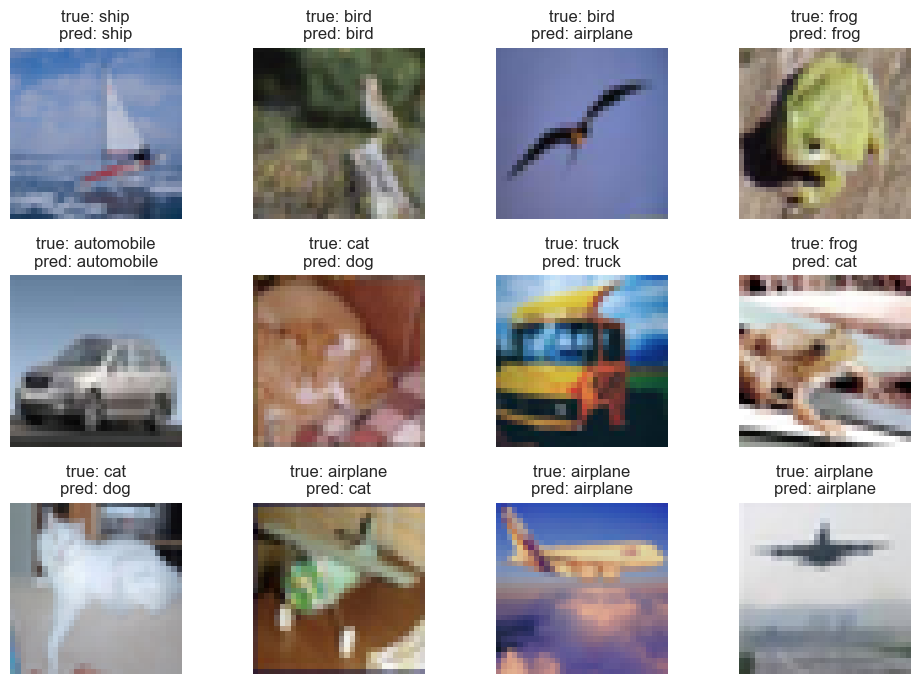

In [ ]:
def show_predictions(dataset, model, labels, n=12):
    indices = np.random.choice(len(dataset), size=n, replace=False)
    fig, axes = plt.subplots(3, 4, figsize=(10, 7))

    model.eval()
    with torch.no_grad():
        for ax, idx in zip(axes.flatten(), indices):
            image, label = dataset[idx]
            input_tensor = image.unsqueeze(0).to(device)
            logits = model(input_tensor)
            pred = torch.argmax(logits, dim=1).item()

            img = denormalize(image, mean, std).clamp(0, 1).permute(1, 2, 0).numpy()
            ax.imshow(img)
            ax.set_title(f"true: {labels[int(label)]}\npred: {labels[int(pred)]}")
            ax.axis("off")

    plt.tight_layout()

show_predictions(test_dataset, model, cifar10_labels)

---
## Part 3: Visualizing What the CNN Learned

This is where it gets really interesting! We'll peek inside the trained CNN to see:
1. **Learned filters**: What patterns did the first layer learn to detect?
2. **Feature maps**: How does an image activate different filters?

This visualization helps us understand WHY the CNN works!

## 11. Visualize Learned Filters

The first convolutional layer learns basic feature detectors. Let's see what our CNN learned!

**What to expect:**
- Edge detectors (horizontal, vertical, diagonal)
- Color/texture patterns
- Blob detectors

These act like the edge/blur kernels we hand-crafted earlier, but **learned automatically** from data!

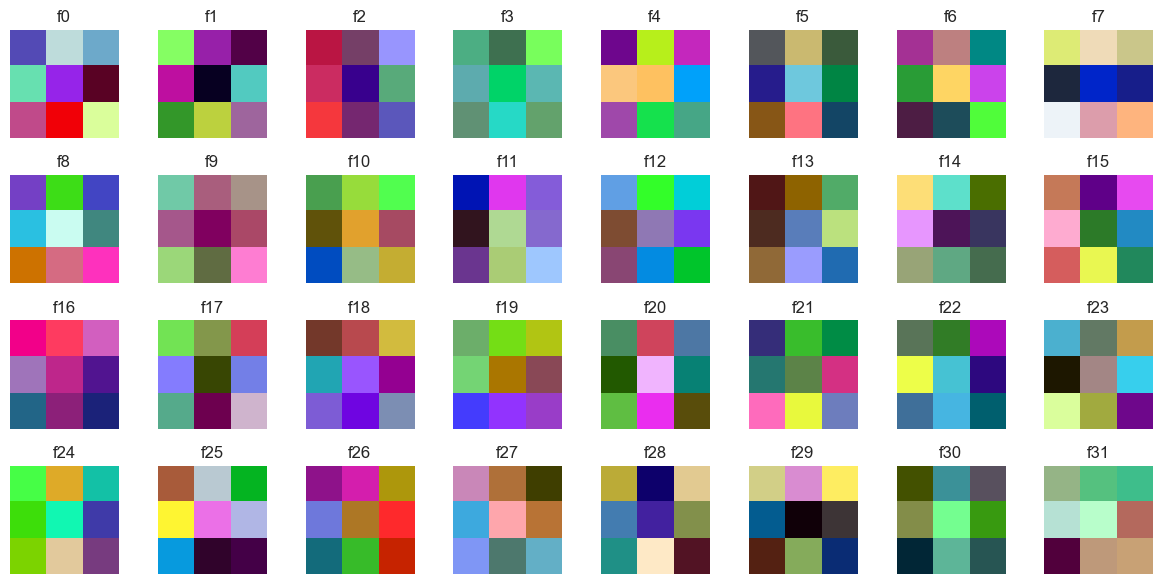

In [ ]:
# Extract first convolutional layer
first_layer = model.features[0]
weights = first_layer.weight.detach().cpu()  # Shape: [32, 3, 3, 3]
num_filters = weights.shape[0]

# Visualize all 32 learned filters
cols = 8
rows = int(np.ceil(num_filters / cols))
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i in range(rows * cols):
    ax = axes.flatten()[i]
    if i < num_filters:
        w = weights[i]  # Shape: [3, 3, 3] (RGB, 3×3 spatial)
        # Normalize to [0, 1] for visualization
        w = (w - w.min()) / (w.max() - w.min() + 1e-6)
        ax.imshow(w.permute(1, 2, 0))  # Convert to HWC for matplotlib
        ax.set_title(f"Filter {i}", fontsize=8)
    ax.axis("off")

plt.suptitle("Learned Filters in First Convolutional Layer (32 filters, 3×3 each)", fontsize=14)
plt.tight_layout()
plt.show()

print("🔍 What to observe:")
print("  • Some filters detect edges (bright-dark transitions)")
print("  • Some respond to specific colors (red/green/blue)")
print("  • Some detect corners or textures")
print("  • Compare to hand-crafted kernels - these were learned from data!")

## 12. Visualize Feature Maps

Now let's see how a real image **activates** these filters. Each filter produces one feature map showing where it detected its pattern.

We'll:
1. Take one test image
2. Pass it through the feature extractor
3. Visualize the resulting feature maps

**Interpretation**: Bright regions in a feature map = strong activation = filter detected its pattern there!

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7830755..2.0942786].


Label: cat


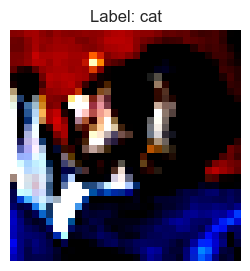

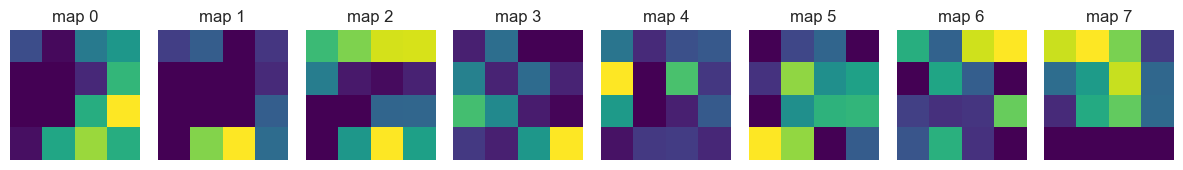

In [ ]:
# Get one test image
sample_image, sample_label = test_dataset[0]

# Pass through feature extractor only (not classifier)
model.eval()
with torch.no_grad():
    fmap = model.features(sample_image.unsqueeze(0).to(device)).cpu()[0]
    # fmap shape: [128, 4, 4] (128 feature maps, each 4×4)

# Show original image
img_vis = denormalize(sample_image, mean, std).clamp(0, 1).permute(1, 2, 0).numpy()
plt.figure(figsize=(4, 4))
plt.imshow(img_vis)
plt.title(f"Original Image: {cifar10_labels[int(sample_label)]}", fontsize=14, fontweight='bold')
plt.axis("off")
plt.tight_layout()
plt.show()

# Show first 12 feature maps from final conv layer
num_maps = min(12, fmap.shape[0])
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for i, ax in enumerate(axes.flatten()):
    if i < num_maps:
        ax.imshow(fmap[i].detach().numpy(), cmap="viridis")
        ax.set_title(f"Feature Map {i}", fontsize=10)
    ax.axis("off")

plt.suptitle("Feature Maps from Final Convolutional Layer (4×4 each)", fontsize=14)
plt.tight_layout()
plt.show()

print(f"📊 Feature Map Analysis:")
print(f"  • Original image: 32×32×3 (RGB)")
print(f"  • After all conv layers: 4×4×128 (128 feature maps)")
print(f"  • Each feature map responds to different patterns")
print(f"  • Bright regions = strong activations = pattern detected!")
print(f"\n💡 Deeper layers detect more complex patterns:")
print(f"  • Layer 1: edges, colors, simple textures")
print(f"  • Layer 2: corners, patterns, combinations")
print(f"  • Layer 3: object parts, complex shapes")

## 13. Summary and Key Takeaways

Congratulations! You've mastered CNN fundamentals. Here's what we learned:

### Core Concepts:
- 🔍 **Convolution**: Local pattern detection with weight sharing
- 📏 **Padding/Stride**: Control output dimensions
- 🔽 **Pooling**: Downsampling for efficiency and invariance
- 🏗️ **Hierarchical features**: Low-level → mid-level → high-level

### Why CNNs Work for Images:
- ✅ **Parameter efficiency**: Millions fewer parameters than fully-connected
- ✅ **Translation invariance**: Detect features anywhere in image
- ✅ **Hierarchical learning**: Automatically learn feature hierarchy
- ✅ **Scalability**: Work for any image size

### Architecture Principles:
- Start with small feature maps, increase depth
- Use 3×3 kernels (efficient and effective)
- BatchNorm + Dropout for regularization
- MaxPool for downsampling

### Practical Insights:
- CNNs learn optimal filters from data
- Deeper layers detect more complex patterns
- Visualization helps understand what the network learned
- Proper data normalization is crucial

**What's next?** Modern architectures (ResNet, EfficientNet) use these same building blocks but with clever tricks like skip connections and attention mechanisms!

---
## 14. Optional Exercises (for early finishers)

### A. Architecture Experiments
1. **Add a fourth conv block**: Does deeper = better here?
2. **Change filter counts**: Try [16, 32, 64] instead of [32, 64, 128]
3. **Remove BatchNorm**: How does training stability change?

### B. Regularization Studies
1. **Vary dropout rate**: Try 0.1, 0.3, 0.5, 0.7 - plot val accuracy vs dropout
2. **Add data augmentation**: Random crops, flips - does it help?
3. **Try different pooling**: Replace MaxPool with AvgPool or strided conv

### C. Visualization Deep Dive
1. **Visualize all layers**: Extract and plot feature maps from each conv block
2. **Filter activation stats**: Which filters activate most strongly? Least?
3. **Class activation maps**: Which image regions were most important for the prediction?

### D. Comparison Study
1. **CNN vs MLP**: Train a fully-connected network on same data - compare:
   - Number of parameters
   - Training time
   - Final test accuracy
2. **Document your findings**: Which architecture is better and why?

<div class="alert alert-block alert-success">
<b>💡 EXPLORATION TIPS</b>

- Change ONE thing at a time
- Keep a log of experiments and results
- Visualize learning curves for each variant
- Think about WHY changes help or hurt

The best way to learn deep learning is by experimenting!
</div>

In [ ]:
# -------------------------------
# INSERT YOUR OWN CODE HERE
# -------------------------------

class CustomCNN(nn.Module):
    """Your custom CNN architecture"""
    def __init__(self, num_classes=10):
        super().__init__()
        # TODO: Design your own architecture
        # Ideas:
        # - More/fewer conv blocks
        # - Different filter sizes (5×5 instead of 3×3?)
        # - Different pooling strategies
        # - Residual connections (add input to output)
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # TODO: Add more layers here
        )
        
        # TODO: Calculate correct input size for classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 16 * 16, num_classes),  # Adjust dimensions!
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# Training template:
"""
# Initialize your model
your_model = CustomCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(your_model.parameters(), lr=1e-3)

# Train
your_history = fit(your_model, train_loader, val_loader, criterion, optimizer, device, epochs=10)

# Evaluate
test_loss, test_acc = evaluate_loader(your_model, test_loader, criterion, device)
print(f"Your model - Test accuracy: {test_acc:.3f}")

# Compare to baseline
print(f"Baseline model - Test accuracy: {test_acc:.3f}")  # from earlier

# Visualize
# - Plot learning curves
# - Show confusion matrix
# - Visualize filters
"""

# TODO: Implement and compare your custom architecture!